In [1]:

import matplotlib.pyplot as plt

from sklearn.datasets import (make_classification, load_iris)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix
)
from sklearn.model_selection import cross_val_score

import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
def make_grid(X, n=300, padding=1.0):
    x0_min, x0_max = X[:, 0].min() - padding, X[:, 0].max() + padding
    x1_min, x1_max = X[:, 1].min() - padding, X[:, 1].max() + padding
    x0_lin = np.linspace(x0_min, x0_max, n)
    x1_lin = np.linspace(x1_min, x1_max, n)

    xx, yy = np.meshgrid(x0_lin, x1_lin)

    xx_ravel = xx.ravel()
    yy_ravel = yy.ravel()

    grid = np.c_[xx_ravel, yy_ravel]

    return xx, yy, grid

def score_on_grid(model, grid):
    scores = model.decision_function(grid)
    min_score, max_score = scores.min(), scores.max()
    return (scores - min_score) / (max_score - min_score)

def find_metrics(model, X_test, y_test):
    pred = model.predict(X_test)

    metrics = {
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
    }

    for name, value in metrics.items():
        print(f"{name}: {value:.4f}")

# Synthetic data

## Generate data

In [3]:
X_simple, y_simple = make_classification(
    n_samples=425,
    n_features=2,          
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.5,         
    flip_y=0.04,
    random_state=2026
)
X_simple[:5] 

array([[ 1.94734403, -0.94551972],
       [ 2.91324296,  3.55511465],
       [-0.45845376, -2.39981727],
       [ 1.97761416,  0.94672866],
       [-2.19010807, -1.2287111 ]])

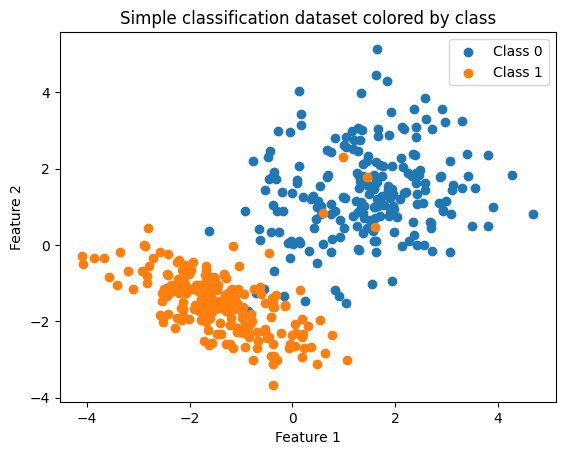

In [4]:
plt.figure()

for cls in (0,1):
    plt.scatter(
        X_simple[y_simple == cls, 0],
        X_simple[y_simple == cls, 1],
        label=f"Class {cls}"
    )
plt.title("Simple classification dataset colored by class")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

## Split data into train and test sets

In [5]:
X_train_simple, X_test_simple, y_train_simple, y_test_simple =  train_test_split(
    X_simple,
    y_simple,
    stratify=y_simple, 
    random_state=2026,
)

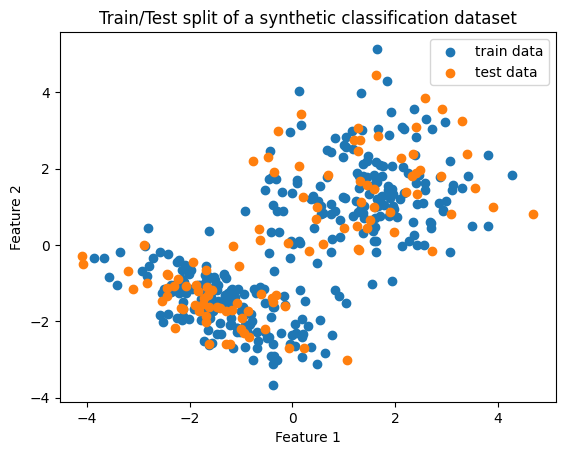

In [6]:
plt.figure()

for t, d in {'train': X_train_simple, 'test': X_test_simple}.items():
    plt.scatter(
        d[:, 0],
        d[:, 1],
        label=f"{t} data"
    )
plt.title("Train/Test split of a synthetic classification dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

## Check classes balance

In [7]:
pd.Series(y_simple).value_counts()

0    214
1    211
Name: count, dtype: int64

## Create and train the model

In [8]:
logreg = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=0.5, max_iter=2000)),
    ]
)

logreg.fit(X_train_simple, y_train_simple)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(C=0.5, max_iter=2000))])

## Make predictions and evaluate the model

In [9]:
find_metrics(logreg, X_test_simple, y_test_simple)

accuracy: 0.9813
precision: 0.9636
recall: 1.0000
f1: 0.9815


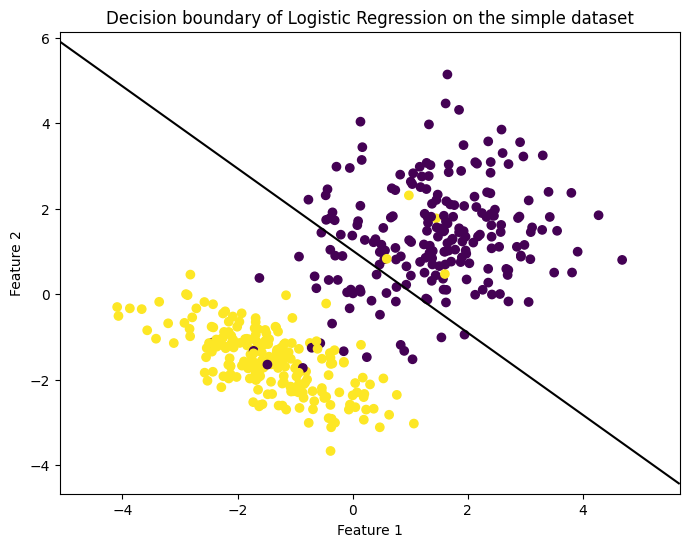

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

xx, yy, grid = make_grid(X_simple)
z = score_on_grid(logreg, grid).reshape(xx.shape)
ax.contour(xx, yy, z, levels=[0.5], colors="black")
ax.scatter(X_simple[:, 0], X_simple[:, 1], c=y_simple)
plt.title("Decision boundary of Logistic Regression on the simple dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Real data

## Load and explore the data

In [11]:
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [12]:
print(f'Class distribution: \n{df_iris["target"].value_counts()}\n')
print(f'Feature distributions: \n{df_iris.describe()}')

Class distribution: 
target
0    50
1    50
2    50
Name: count, dtype: int64

Feature distributions: 
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max    

Check for overlapping between classes.

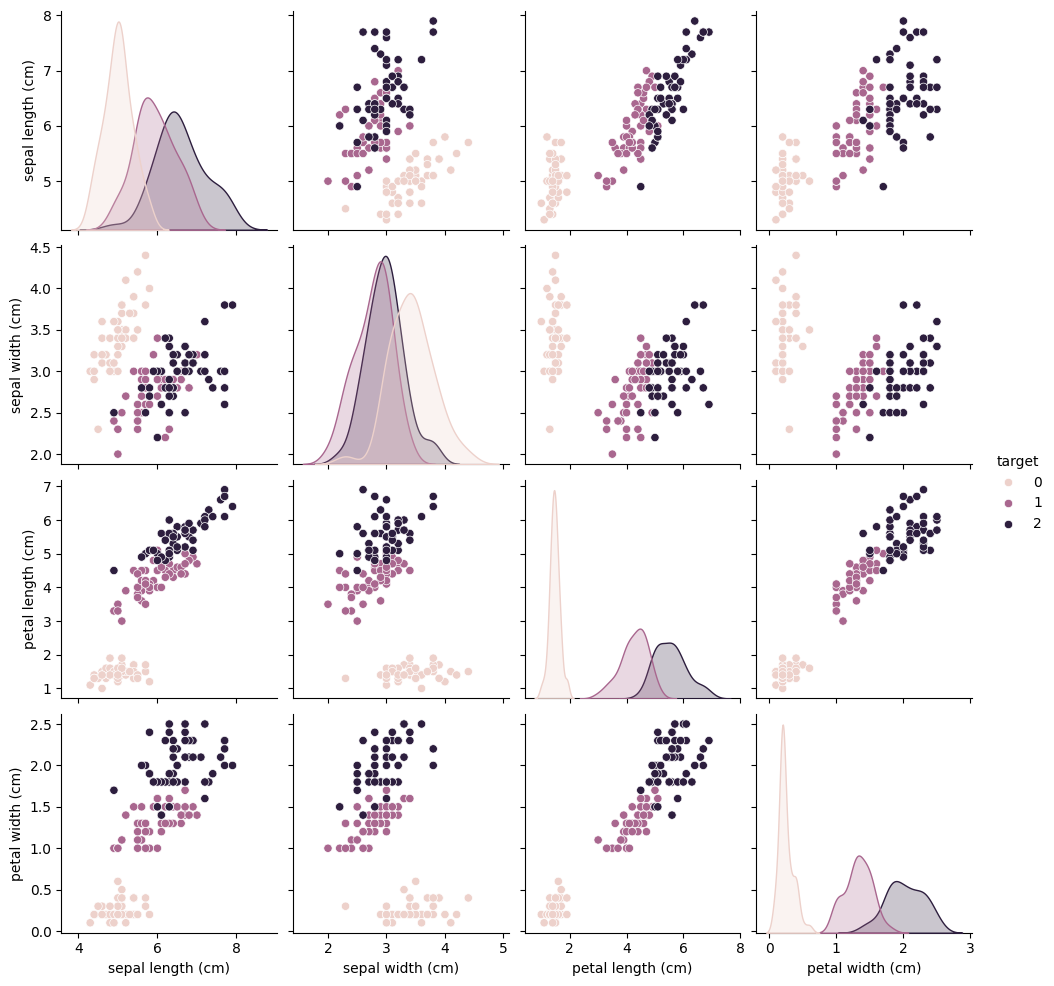

In [13]:
sns.pairplot(df_iris, hue="target")

## Binary Iris classification

### Prepare data

Classes 1 and 2 slightly overlap, so they were selected for binary classification.

In [14]:
df_iris_2 = df_iris[df_iris['target'] != 0]
df_iris_2['target'].unique()

array([1, 2])

In [15]:
X_train_ir2, X_test_ir2, y_train_ir2, y_test_ir2 = train_test_split(
    df_iris_2.drop('target', axis=1),
    df_iris_2['target'],
    
    random_state=42
)

### Create and train the model

In [ ]:
logreg_ir2 = Pipeline([
    # ("poly", PolynomialFeatures(degree=3)), # both commented lines return the same results
    # ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=2000))
])
logreg_ir2.fit(X_train_ir2, y_train_ir2)

Pipeline(steps=[('logreg', LogisticRegression(max_iter=2000))])

### Make predictions and evaluate the model

In [17]:
find_metrics(logreg_ir2, X_test_ir2, y_test_ir2)

accuracy: 0.9200
precision: 0.9286
recall: 0.9286
f1: 0.9286


In [18]:
cross_val_score(logreg_ir2,  df_iris_2.drop('target', axis=1), df_iris_2['target'], cv=5)

array([0.95, 1.  , 0.9 , 0.95, 1.  ])

## Multiclass Iris clasification

### Split data

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    df_iris.drop('target', axis=1),
    df_iris['target'],
    
    random_state=42
)

### Create and train the model

In [20]:
logreg = Pipeline([
    ('logreg', LogisticRegression(max_iter=2000))
])
logreg.fit(X_train, y_train)

Pipeline(steps=[('logreg', LogisticRegression(max_iter=2000))])

### Make predictions and evaluate the model

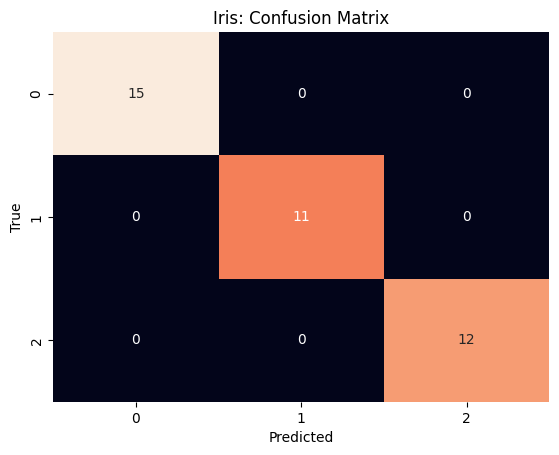

Accuracy: 1.0000


In [21]:
pred = logreg.predict(X_test)
cm_iris = confusion_matrix(y_test, pred)
sns.heatmap(
    cm_iris,
    annot=True,
    fmt="d",
    cbar=False)

plt.title("Iris: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

print(f"Accuracy: {accuracy_score(y_test, pred):.4f}")

The score is suspiciously high, so I performed cross-validation.

In [22]:
cross_val_score(logreg,  df_iris.drop('target', axis=1), df_iris['target'], cv=5)

array([0.96666667, 1.        , 0.93333333, 0.96666667, 1.        ])